## Importing necessary libraries

In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
warnings.filterwarnings('ignore')

## Importing cleaned dataset

In [122]:
house_df = pd.read_csv('../datat/df11_final_cleaned.csv')
house_df.head()

,sold_price,lot_acres,bedrooms,bathrooms,sqrt_ft,garage,fireplaces,has_Dishwasher,has_Oven,has_Refrigerator,...,loc__85745,loc__85747,loc__85748,loc__85749,loc__85750,loc__85755,loc__85901,loc__85929,loc__85935,loc__86323
0,1100000.0,1.39,4,4.0,5164.0,3.0,4,1,1,1,...,0,0,0,0,0,1,0,0,0,0
1,1150000.0,11.49,4,5.0,4330.0,3.0,3,1,1,1,...,0,0,0,1,0,0,0,0,0,0
2,1200000.0,1.21,4,4.0,4426.0,3.0,0,1,1,1,...,0,0,0,0,1,0,0,0,0,0
3,1200000.0,7.11,3,3.0,3528.0,2.0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,1120150.0,2.98,4,6.0,4050.0,4.0,2,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [123]:
# house_df.info()

In [124]:
house_df.isna().sum()

sold_price    0
lot_acres     0
bedrooms      0
bathrooms     0
sqrt_ft       0
             ..
loc__85755    0
loc__85901    0
loc__85929    0
loc__85935    0
loc__86323    0
Length: 73, dtype: int64

No missing data and the data has 4410 observations and 73 columns

## Classifiers and Regressors for the dataset

In [125]:
## KNN Classifier - chosen because of its higher accuracy
class KNNClassifier():
  #defining training function
  def fit(self, X, y):
    self.X = X
    self.y = y

  #defining prediction function
  def predict(self, X, K, epsilon = 1e-3):
    N = len(X)
    y_hat = np.zeros(N)
    X = np.array(X)
    self.X = np.array(self.X)
     # get squared values outside the loop to reduce computation time
    X_square_sum = np.sum(X**2, axis=1)
    train_square_sum = np.sum(self.X**2, axis=1)
    dist2 = -2 * (X @ self.X.T) + X_square_sum[:, None] + train_square_sum

    for i in range(N):
        idxt = np.argsort(dist2[i])[:K]
        gamma_k = 1 / (np.sqrt(dist2[i, idxt] + epsilon))
        y_hat[i] = np.bincount(self.y[idxt], weights=gamma_k).argmax()

    return y_hat.astype(int)

  def accuracy(self, y, y_pred):
    return np.mean((y==y_pred))

## Multivariate Regression model
class MVLinearRegression():
  def fit(self, X, y, eta=1e-3, epochs=1e3, show_curve=False):
    epochs = int(epochs)
    N, D = X.shape
    Y = y
    #Begin optimizations
    self.w = np.random.randn(D)
    self.j = np.zeros(epochs)

    #stochastic Gradient Descent
    for epoch in range(epochs):
      y_hat = self.predict(X)
      self.j[epoch] = OLS(X,y, y_hat)
      #weight update rule
      self.w -= eta*(1/N)*(X.T@(y_hat-Y))
    if show_curve:
      plt.figure(figsize=(5,4))
      plt.plot(self.j)
      plt.xlabel('Epochs')
      plt.ylabel('$\mathcal{j}$')
      plt.title('Training Curve')
      plt.show()
  def predict(self, X):
    return X@self.w
# MV Ridge regression (L2)
class RidgeRegression():
    def fit(self, X, y, eta=1e-3, epochs=1e3, lambda_=1, show_curve=False):
        epochs = int(epochs)
        N, D = X.shape
        Y = y
        self.w = np.random.randn(D)
        self.j = np.zeros(epochs)

        # Stochastic Gradient Descent
        for epoch in range(epochs):
            y_hat = self.predict(X)
            # Calculate the cost function with # L2 regularization
            self.j[epoch] = OLS(X, y, y_hat) + (lambda_/2) * np.sum(self.w**2)

            # calculate gradient against the weights
            grad_w = (1/N) * (X.T @ (y_hat - Y))
            self.w -= eta * (grad_w + lambda_ * self.w)

        if show_curve:
            plt.figure(figsize=(5,4))
            plt.plot(self.j)
            plt.xlabel('Epochs')
            plt.ylabel('$\mathcal{j}$')
            plt.title('Training Curve')
            plt.show()

    def predict(self, X):
        return X @ self.w

# KNN Regressor
class KNNRegressor():
  def fit(self, X, y):
    self.X = X
    self.y = y
  def predict(self, X, k, epsilon=1e-3):
    N = len(X)
    y_hat = np.zeros(N)
    for i in range(N):
      dist2 = np.sum((self.X-X[i])**2, axis=1)
      idx = np.argsort(dist2)[:k]
      gamma_k = np.exp(-dist2[idx])/(np.exp(dist2[idx]).sum() + epsilon)
      y_hat[i] = gamma_k @ self.y[idx]

    return y_hat


## Functions

In [126]:
def get_house_price_quantiles(df, column_name, quantiles=[0.1, 0.25, 0.5, 0.75, 0.9]):
    return df[column_name].quantile(quantiles).to_dict()

# {0.1: 550000.0, 0.25: 580000.0, 0.5: 657500.0, 0.75: 779000.0, 0.9: 925000.0}
def classify_affordability(price):
    if price < 550000:
        # return 'very cheap'
        return 1
    elif 550000 <= price < 580000:
        # return 'cheap'
        return 2
    elif 580000 <= price < 657500:
        # return 'affordable'
        return 3
    elif 657500 <= price < 779000:
        # return 'expensive'
        return 4
    else:
        # return 'very expensive'
        return 5

def train_test_split(X, y, test_size):
    split_point = int(len(X) * (1 - test_size))
    # Split data
    X_train = X[:split_point]
    X_test = X[split_point:]
    y_train = y[:split_point]
    y_test = y[split_point:]

    return X_train, X_test, y_train, y_test

def OLS(X, y, y_hat):
  N = y_hat.shape[0]
  return np.sum((y_hat-y)**2)/(2*N)

def minmax_scaler(data):
    min_val = np.min(data)
    max_val = np.max(data)
    scaled_values = (data - min_val) / (max_val - min_val)
    return scaled_values
def scale_single_pred_value(value, min_val, max_val):
    scaled_value = (value - min_val) / (max_val - min_val)
    return scaled_value
def MAPE(y,y_hat):
  return round(np.mean(np.abs((y-y_hat)/y))*100,2)
def inverse_transform(column):
    return 1 / np.where(column != 0, column, 1)
def predict_house_price(model, zipcode,bathrooms, sqrt_ft, fireplaces, house_age, has_Dishwasher, has_Oven, has_Refrigerator, has_Freezer, has_Microwave, has_Countertops, has_Pantry, has_Others_appliances):
    loc_index = np.where(X2.columns==f'loc__{zipcode}')[0][0]
    bath_min = 1
    bath_max = 36

    sqrt_ft_min = 1484
    sqrt_ft_max = 5709

    fire_min = 0
    fire_max = 9

    bathrooms = scale_single_pred_value(bathrooms, bath_min, bath_max)
    sqrt_ft = scale_single_pred_value(sqrt_ft, sqrt_ft_min, sqrt_ft_max)
    fireplaces = scale_single_pred_value(fireplaces, fire_min, fire_max)
    house_age = inverse_transform(house_age)

    x = np.zeros(len(X2.columns))
    x[0] = bathrooms
    x[1] = sqrt_ft
    x[2] = fireplaces
    x[3] = house_age
    x[4] = has_Dishwasher
    x[5] = has_Oven
    x[6] = has_Refrigerator
    x[7] = has_Freezer
    x[8] = has_Microwave
    x[9] = has_Countertops
    x[10] = has_Pantry
    x[11] = has_Others_appliances

    if loc_index >= 0:
        x[loc_index] = 1

    return model.predict([x])[0]
#Get house predictions for same client requirements across all zipcodes
def get_house_predictions(model, zipcodes, bathrooms, sqrt_ft, fireplaces, house_age, has_Dishwasher, has_Oven, has_Refrigerator, has_Freezer, has_Microwave, has_Countertops, has_Pantry, has_Others_appliances):
  zip_location_with_predicted_price = {}
  for zipcode in zipcodes:
    predicted = round(predict_house_price(model, zipcode, bathrooms, sqrt_ft, fireplaces, house_age, has_Dishwasher, has_Oven, has_Refrigerator, has_Freezer, has_Microwave, has_Countertops, has_Pantry, has_Others_appliances),2)
    zip_location_with_predicted_price[zipcode] = predicted
  return zip_location_with_predicted_price
def get_min_max_from_dict(data_dict):
    min_zip = min(data_dict, key=data_dict.get)
    max_zip = max(data_dict, key=data_dict.get)
    print(f"The cheapest house with selected features is located at : {min_zip}, Price is: {data_dict[min_zip]}")
    print(f"The most expensive house with selected features is located at : {max_zip}, Price is: {data_dict[max_zip]}")
    return {min_zip: data_dict[min_zip]}, {max_zip: data_dict[max_zip]}

In [127]:
#Transform house age column to establish a negative correlation with the price.
# An older house should have a lower price compared to the newest houses
house_df['house_age_transformed'] = inverse_transform(house_df['house_age'])
house_df.head()

,sold_price,lot_acres,bedrooms,bathrooms,sqrt_ft,garage,fireplaces,has_Dishwasher,has_Oven,has_Refrigerator,...,loc__85747,loc__85748,loc__85749,loc__85750,loc__85755,loc__85901,loc__85929,loc__85935,loc__86323,house_age_transformed
0,1100000.0,1.39,4,4.0,5164.0,3.0,4,1,1,1,...,0,0,0,0,1,0,0,0,0,0.043478
1,1150000.0,11.49,4,5.0,4330.0,3.0,3,1,1,1,...,0,0,1,0,0,0,0,0,0,0.058824
2,1200000.0,1.21,4,4.0,4426.0,3.0,0,1,1,1,...,0,0,0,1,0,0,0,0,0,0.045455
3,1200000.0,7.11,3,3.0,3528.0,2.0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0.019231
4,1120150.0,2.98,4,6.0,4050.0,4.0,2,1,1,1,...,0,0,0,0,0,0,0,0,0,0.058824


In [128]:
house_df.columns

Index(['sold_price', 'lot_acres', 'bedrooms', 'bathrooms', 'sqrt_ft', 'garage',
       'fireplaces', 'has_Dishwasher', 'has_Oven', 'has_Refrigerator',
       'has_Freezer', 'has_Microwave', 'has_Countertops', 'has_Pantry',
       'has_Others_appliances', 'house_age', 'has_Carpet', 'has_Tile',
       'has_Wood', 'has_Natural Stone', 'has_Concrete', 'has_other_floors',
       'loc__85118', 'loc__85192', 'loc__85541', 'loc__85602', 'loc__85605',
       'loc__85610', 'loc__85611', 'loc__85614', 'loc__85615', 'loc__85619',
       'loc__85621', 'loc__85622', 'loc__85623', 'loc__85624', 'loc__85625',
       'loc__85629', 'loc__85630', 'loc__85637', 'loc__85640', 'loc__85641',
       'loc__85643', 'loc__85645', 'loc__85646', 'loc__85648', 'loc__85658',
       'loc__85701', 'loc__85704', 'loc__85705', 'loc__85710', 'loc__85711',
       'loc__85712', 'loc__85713', 'loc__85715', 'loc__85716', 'loc__85718',
       'loc__85719', 'loc__85730', 'loc__85737', 'loc__85739', 'loc__85742',
       'loc__8

<Axes: >

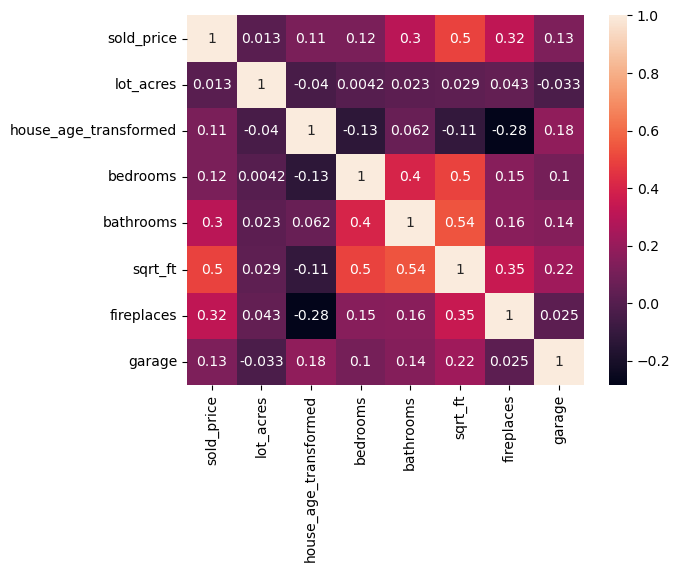

In [129]:
#Get correlation matrix among major variables
sns.heatmap(house_df[['sold_price', 'lot_acres', 'house_age_transformed','bedrooms', 'bathrooms', 'sqrt_ft','fireplaces','garage']].corr(), annot=True)

In [130]:
#Data of interest
mod_data = house_df.drop(columns=['lot_acres','house_age', 'bedrooms', 'garage', 'has_Wood', 'has_Natural Stone', 'has_Concrete', 'has_other_floors','has_Carpet','has_Tile'], axis=1)

### Reasons for some columns
- Have a weak correlation with the house price e.e lot_acres
- Not required in the model
- Autocorrelation between bedrooms and bathrooms

In [131]:
mod_data.head()

,sold_price,bathrooms,sqrt_ft,fireplaces,has_Dishwasher,has_Oven,has_Refrigerator,has_Freezer,has_Microwave,has_Countertops,...,loc__85747,loc__85748,loc__85749,loc__85750,loc__85755,loc__85901,loc__85929,loc__85935,loc__86323,house_age_transformed
0,1100000.0,4.0,5164.0,4,1,1,1,1,1,0,...,0,0,0,0,1,0,0,0,0,0.043478
1,1150000.0,5.0,4330.0,3,1,1,1,0,1,0,...,0,0,1,0,0,0,0,0,0,0.058824
2,1200000.0,4.0,4426.0,0,1,1,1,0,1,0,...,0,0,0,1,0,0,0,0,0,0.045455
3,1200000.0,3.0,3528.0,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.019231
4,1120150.0,6.0,4050.0,2,1,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0.058824


In [132]:
mod_data.columns

Index(['sold_price', 'bathrooms', 'sqrt_ft', 'fireplaces', 'has_Dishwasher',
       'has_Oven', 'has_Refrigerator', 'has_Freezer', 'has_Microwave',
       'has_Countertops', 'has_Pantry', 'has_Others_appliances', 'loc__85118',
       'loc__85192', 'loc__85541', 'loc__85602', 'loc__85605', 'loc__85610',
       'loc__85611', 'loc__85614', 'loc__85615', 'loc__85619', 'loc__85621',
       'loc__85622', 'loc__85623', 'loc__85624', 'loc__85625', 'loc__85629',
       'loc__85630', 'loc__85637', 'loc__85640', 'loc__85641', 'loc__85643',
       'loc__85645', 'loc__85646', 'loc__85648', 'loc__85658', 'loc__85701',
       'loc__85704', 'loc__85705', 'loc__85710', 'loc__85711', 'loc__85712',
       'loc__85713', 'loc__85715', 'loc__85716', 'loc__85718', 'loc__85719',
       'loc__85730', 'loc__85737', 'loc__85739', 'loc__85742', 'loc__85743',
       'loc__85745', 'loc__85747', 'loc__85748', 'loc__85749', 'loc__85750',
       'loc__85755', 'loc__85901', 'loc__85929', 'loc__85935', 'loc__86323',
   

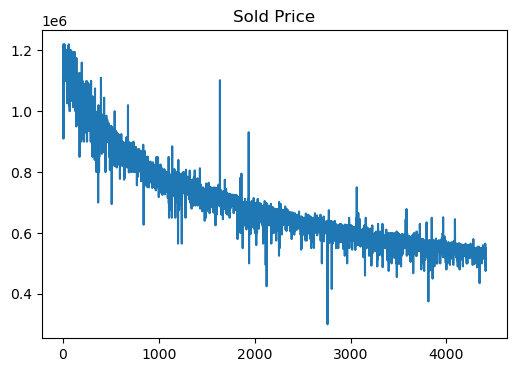

In [133]:
#check the trend of sold price
plt.figure(figsize=(6,4))
plt.plot(mod_data['sold_price'])
plt.title('Sold Price')
plt.show()

In [134]:
#Used quantiles to classify house prices on affordability
quantile_values = get_house_price_quantiles(mod_data, 'sold_price', quantiles=[0.1, 0.25, 0.5, 0.75, 0.9])
print(quantile_values)

{0.1: 550000.0, 0.25: 580000.0, 0.5: 657500.0, 0.75: 779000.0, 0.9: 925000.0}


In [135]:
mod_data['affordability'] = mod_data['sold_price'].apply(classify_affordability)
mod_data.head()

,sold_price,bathrooms,sqrt_ft,fireplaces,has_Dishwasher,has_Oven,has_Refrigerator,has_Freezer,has_Microwave,has_Countertops,...,loc__85748,loc__85749,loc__85750,loc__85755,loc__85901,loc__85929,loc__85935,loc__86323,house_age_transformed,affordability
0,1100000.0,4.0,5164.0,4,1,1,1,1,1,0,...,0,0,0,1,0,0,0,0,0.043478,5
1,1150000.0,5.0,4330.0,3,1,1,1,0,1,0,...,0,1,0,0,0,0,0,0,0.058824,5
2,1200000.0,4.0,4426.0,0,1,1,1,0,1,0,...,0,0,1,0,0,0,0,0,0.045455,5
3,1200000.0,3.0,3528.0,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0.019231,5
4,1120150.0,6.0,4050.0,2,1,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0.058824,5


In [136]:
X = mod_data.drop(columns=['affordability'], axis=1)
y = mod_data['affordability']

In [137]:
X.head()

,sold_price,bathrooms,sqrt_ft,fireplaces,has_Dishwasher,has_Oven,has_Refrigerator,has_Freezer,has_Microwave,has_Countertops,...,loc__85747,loc__85748,loc__85749,loc__85750,loc__85755,loc__85901,loc__85929,loc__85935,loc__86323,house_age_transformed
0,1100000.0,4.0,5164.0,4,1,1,1,1,1,0,...,0,0,0,0,1,0,0,0,0,0.043478
1,1150000.0,5.0,4330.0,3,1,1,1,0,1,0,...,0,0,1,0,0,0,0,0,0,0.058824
2,1200000.0,4.0,4426.0,0,1,1,1,0,1,0,...,0,0,0,1,0,0,0,0,0,0.045455
3,1200000.0,3.0,3528.0,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.019231
4,1120150.0,6.0,4050.0,2,1,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0.058824


In [138]:
X = X.loc[:, ~X.columns.str.startswith('loc__')]

<Figure size 600x400 with 0 Axes>

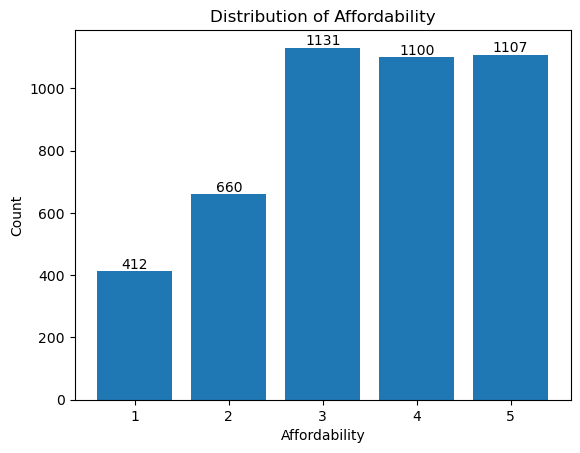

In [139]:
#plot distribution of houses per classification
dist = y.value_counts()

plt.figure(figsize=(6,4))
fig, ax = plt.subplots()
bars = ax.bar(dist.index, dist.values)

# Adding labels on the bars
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

plt.title('Distribution of Affordability')
plt.xlabel('Affordability')
plt.ylabel('Count')
plt.show()

In [140]:
#Train_test_split the data for feeding into KNN classifier
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## Classification

In [141]:
knn_classifier = KNNClassifier()
knn_classifier.fit(X_train.values, y_train.values)

In [142]:
y_pred = knn_classifier.predict(X_test.values, K=5)

In [143]:
y_pred[:5]

array([3, 3, 2, 1, 1])

In [144]:
y_test[:5]

3528    3
3529    3
3530    2
3531    1
3532    1
Name: affordability, dtype: int64

In [145]:
knn_classifier.accuracy(y_test.values, y_pred)

0.9909297052154195

Text(0.5, 14.722222222222216, 'y_predicted')

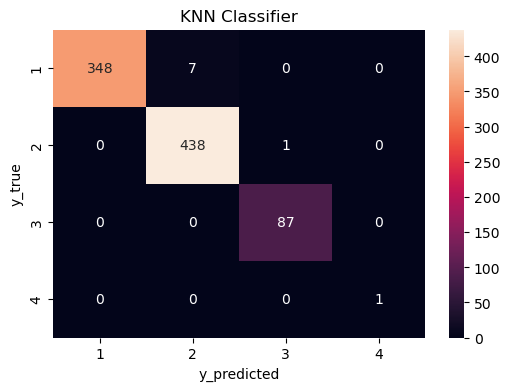

In [146]:
#Plot KNN confusion matrix
plt.figure(figsize=(6,4))
y_actual = pd.Series(y_test.values, name='Actual')
y_predicted = pd.Series(y_pred, name='Predicted')
cm = pd.crosstab(y_actual, y_predicted)
ax = sns.heatmap(cm, annot=True, fmt="d")
plt.title("KNN Classifier")
plt.ylabel('y_true')
plt.xlabel('y_predicted')

In [147]:
knn_classifier.predict([[700000, 4,2000, 2, 1,1,1,1,1,1,1,1,2]], K=6)

array([4])

## Regression

In [148]:
#Build regression to calculate the values and classify the house,
#then select all potential houses the customer can buy instead of this and the features the house has

In [149]:
mod_data.columns

Index(['sold_price', 'bathrooms', 'sqrt_ft', 'fireplaces', 'has_Dishwasher',
       'has_Oven', 'has_Refrigerator', 'has_Freezer', 'has_Microwave',
       'has_Countertops', 'has_Pantry', 'has_Others_appliances', 'loc__85118',
       'loc__85192', 'loc__85541', 'loc__85602', 'loc__85605', 'loc__85610',
       'loc__85611', 'loc__85614', 'loc__85615', 'loc__85619', 'loc__85621',
       'loc__85622', 'loc__85623', 'loc__85624', 'loc__85625', 'loc__85629',
       'loc__85630', 'loc__85637', 'loc__85640', 'loc__85641', 'loc__85643',
       'loc__85645', 'loc__85646', 'loc__85648', 'loc__85658', 'loc__85701',
       'loc__85704', 'loc__85705', 'loc__85710', 'loc__85711', 'loc__85712',
       'loc__85713', 'loc__85715', 'loc__85716', 'loc__85718', 'loc__85719',
       'loc__85730', 'loc__85737', 'loc__85739', 'loc__85742', 'loc__85743',
       'loc__85745', 'loc__85747', 'loc__85748', 'loc__85749', 'loc__85750',
       'loc__85755', 'loc__85901', 'loc__85929', 'loc__85935', 'loc__86323',
   

In [150]:
# mod_data.house_age

In [151]:
X2 = mod_data.drop(columns=['sold_price', 'affordability'], axis=1)
y2 = mod_data['sold_price']


In [152]:
#Scale the sqrt_ft, fireplaces and bathrooms values
X2['sqrt_ft'] = minmax_scaler(X2['sqrt_ft'])
X2['fireplaces'] = minmax_scaler(X2['fireplaces'])
X2['bathrooms'] = minmax_scaler(X2['bathrooms'])
X2.head()

,bathrooms,sqrt_ft,fireplaces,has_Dishwasher,has_Oven,has_Refrigerator,has_Freezer,has_Microwave,has_Countertops,has_Pantry,...,loc__85747,loc__85748,loc__85749,loc__85750,loc__85755,loc__85901,loc__85929,loc__85935,loc__86323,house_age_transformed
0,0.085714,0.866902,0.444444,1,1,1,1,1,0,0,...,0,0,0,0,1,0,0,0,0,0.043478
1,0.114286,0.670436,0.333333,1,1,1,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0.058824
2,0.085714,0.693051,0.000000,1,1,1,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0.045455
3,0.057143,0.481508,0.111111,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.019231
4,0.142857,0.604476,0.222222,1,1,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0.058824


In [153]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2)

In [154]:
X_train2

,bathrooms,sqrt_ft,fireplaces,has_Dishwasher,has_Oven,has_Refrigerator,has_Freezer,has_Microwave,has_Countertops,has_Pantry,...,loc__85747,loc__85748,loc__85749,loc__85750,loc__85755,loc__85901,loc__85929,loc__85935,loc__86323,house_age_transformed
0,0.085714,0.866902,0.444444,1,1,1,1,1,0,0,...,0,0,0,0,1,0,0,0,0,0.043478
1,0.114286,0.670436,0.333333,1,1,1,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0.058824
2,0.085714,0.693051,0.000000,1,1,1,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0.045455
3,0.057143,0.481508,0.111111,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.019231
4,0.142857,0.604476,0.222222,1,1,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0.058824
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3523,0.057143,0.573380,0.222222,1,1,1,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0.022222
3524,0.085714,0.421201,0.111111,1,1,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0.055556
3525,0.085714,0.500353,0.111111,1,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0.111111
3526,0.057143,0.305065,0.222222,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.014493


In [155]:
len(X_test2.columns)

63

In [156]:
X_train2 = X_train2.to_numpy()
X_test2 = X_test2.to_numpy()
y_train2 = y_train2.to_numpy()
y_test2 = y_test2.to_numpy()

In [157]:
y_train2.shape

(3528,)

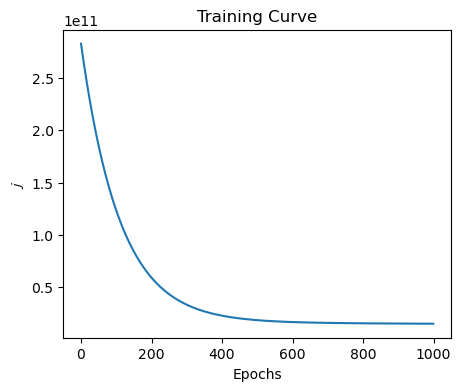

In [158]:
mvlr_reg = MVLinearRegression()
mvlr_reg.fit(X_train2, y_train2, show_curve=True)

In [159]:
y_pred2 = mvlr_reg.predict(X_test2)

In [160]:
y_pred2[:5]

array([553324.26732512, 593939.32715048, 701415.87599208, 482761.29229498,
       532371.82522746])

In [161]:
y_test2[:5]

array([585000., 585000., 565000., 532500., 525000.])

In [162]:
#Check mean abs percentage error
print(f'The MAPE for MVLR is: {MAPE(y_test2, y_pred2)}%')


The MAPE for MVLR is: 28.56%


## Insights from Multivariate Linear Regression MAPE
- The MAPE is 28.56% suggesting that the price of houses deviates from the actual values in +/- 28.61%. This deviation shows that the model's accuracy is a little lower.
- After adding regularization (L2 - Ridge regression)- the MAPE dropped to 15.56% which is a significant improvement suggesting that the predicted values deviate from the actual prices by only 15.56% which is less than the initial 28.56%.

#### Trying to reduce MAPE through feature engineering, trying different regressors or regularization

### Ridge regression

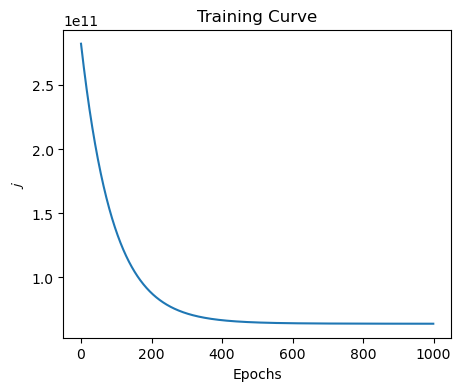

In [163]:
l2_reg = RidgeRegression()
l2_reg.fit(X_train2, y_train2, lambda_=1, show_curve=True)

In [164]:
import joblib
joblib.dump(l2_reg, 'HousePriceDecisionModel.model')

['HousePriceDecisionModel.model']

In [165]:
#Get predictions for Ridge regression
y_pred3 = l2_reg.predict(X_test2)
y_pred3[:5]

array([452063.47921909, 485534.39282969, 577691.88961605, 394413.08357618,
       440243.65233041])

In [166]:
#Ridge regression MAPE
print(f'The MAPE for Ridge Regression: {MAPE(y_test2, y_pred3)}%')

The MAPE for Ridge Regression: 15.59%


In [167]:
## KNN Regressor
knn_regressor = KNNRegressor()
knn_regressor.fit(X_train2, y_train2)

In [168]:
y_pred4 = knn_regressor.predict(X_test2, k=6)

In [169]:
y_pred4[:5]

array([135282.53406732, 695201.83088542, 571397.11212363,  77416.01261962,
         9926.64640385])

In [170]:
y_test2[:5]

array([585000., 585000., 565000., 532500., 525000.])

In [171]:
#KNN regressor MAPE
print(f'The MAPE for KNN Regression is: {MAPE(y_test2, y_pred4)}%')

The MAPE for KNN Regression is: 37.75%


#### Findings from KNNRegressor
  - KNNRegressor model performed even poorly with an MAPE score of 37.75% which is higher compared to multivariate linear regression model.
  - KNNRegressor does not calculate any weights during the training, thus, no need to perform any regularization.

### Ploting the MAPE comparison charts for various models tested.

Text(0.5, 1.0, 'Comparison of MAPE for Different Models')

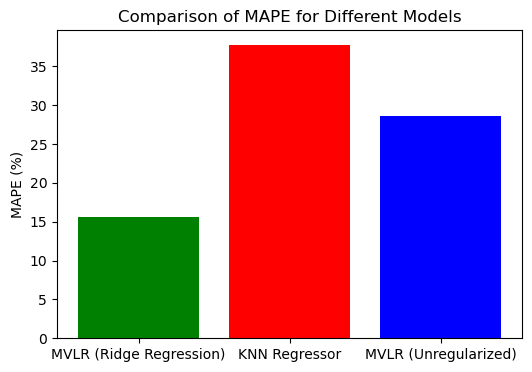

In [172]:
models = ['MVLR (Ridge Regression)', 'KNN Regressor', 'MVLR (Unregularized)']
mape_values = [15.59, 37.75, 28.56]
plt.figure(figsize=(6, 4))
plt.bar(models, mape_values, color=['green', 'red', 'blue'])
plt.ylabel('MAPE (%)')
plt.title('Comparison of MAPE for Different Models')

In [173]:
#Used this here to get the min and max values for variables of interest in building the model
mod_data.describe()

,sold_price,bathrooms,sqrt_ft,fireplaces,has_Dishwasher,has_Oven,has_Refrigerator,has_Freezer,has_Microwave,has_Countertops,...,loc__85748,loc__85749,loc__85750,loc__85755,loc__85901,loc__85929,loc__85935,loc__86323,house_age_transformed,affordability
count,4.410000e+03,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000,...,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000,4410.000000
mean,6.996795e+05,3.649433,3499.913288,1.763719,0.980045,0.810431,0.843084,0.065079,0.731066,0.301134,...,0.012925,0.084807,0.158277,0.096599,0.000227,0.000227,0.000227,0.000227,0.046195,3.414966
std,1.526536e+05,0.979551,717.657342,1.035303,0.139860,0.392005,0.363763,0.246694,0.443456,0.458803,...,0.112965,0.278626,0.365042,0.295444,0.015058,0.015058,0.015058,0.015058,0.031406,1.266901
min,3.000000e+05,1.000000,1484.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.007634,1.000000
25%,5.800000e+05,3.000000,3004.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.027027,3.000000
50%,6.575000e+05,4.000000,3426.500000,2.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.040000,4.000000
75%,7.790000e+05,4.000000,3929.000000,2.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.052632,5.000000
max,1.220000e+06,36.000000,5729.000000,9.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.200000,5.000000


In [174]:
# #scale data for predictions' testing
# bath_min = 1
# bath_max = 36

# sqrt_ft_min = 1484
# sqrt_ft_max = 5709

# fire_min = 0
# fire_max = 9

# bathrooms = scale_single_pred_value(2, bath_min, bath_max)
# sqrt_ft = scale_single_pred_value(2000, sqrt_ft_min, sqrt_ft_max)
# fireplaces = scale_single_pred_value(2, fire_min, fire_max)
# house_age = inverse_transform(10)


In [175]:
# Get all location columns
loc_cols = [col for col in mod_data.columns if col.startswith('loc_')]
# print(loc_cols)
#get all zipcodes without
zipcodes = [int(col.split('__')[1]) for col in loc_cols]
# print(zipcodes)
#Show most expensive and cheapest house price and location, with the same features set by customer
model = l2_reg
min_price, max_price = get_min_max_from_dict(get_house_predictions(model, zipcodes, 10, 5000, 3,0, 1,1,1,1,1,1,1,1))


The cheapest house with selected features is located at : 85605, Price is: 730482.26
The most expensive house with selected features is located at : 85718, Price is: 769881.55


In [176]:
knn_classifier.predict([[max_price[85718], 4, 3000, 3,10, 1,1,1,1,1,1,1,1]], K=6)

array([4])

### Conclusion
- The L2 regularized (Ridge regression) performed the best in predicting the house prices with a low MAPE compared to KNN Regressor and Multivariate regresson, and KNN was the best classifier for prediced house prices with an accuracy of 99.09%.

## Future improvements

In [177]:
#Determine if a good deal or not
# def good_deal(zipcode, paid_price, min_price, max_price):
#     if paid_price > max_price[zipcode]:
#         return 'Bad deal'
#     elif paid_price <= min_price[zipcode]:
#         return 'Good deal'
#     else:
#         return 'Fair price'

# good_deal(85605, 650000, min_price[85605], max_price[85605])

In [178]:
model_loaded = joblib.load('HousePriceDecisionModel.model')

In [179]:
# model_loaded.predict()
predict_house_price(model_loaded, 85605, 10, 2000, 3,20, 1,1,1,1,1,1,1,1)

547752.4824548418

In [180]:
# write zipcodes to json file
output_zips = {"zipcodes": zipcodes}

# Save the dictionary to a JSON file
with open('zipcodes.json', 'w') as file:
    json.dump(output_zips, file, indent=4)